In [1]:
import MDAnalysis as mda
from numpy import *
import os
from pylab import *
import MDAnalysis.analysis.distances
import MDAnalysis.analysis.rms
from MDAnalysis.analysis import align
import glob
#import umap
import scipy.stats
import sklearn
import sklearn.decomposition
import sklearn.preprocessing
import pandas as pd
import seaborn as sns
from MDAnalysis.analysis.hydrogenbonds.hbond_analysis import HydrogenBondAnalysis as HBA

In [2]:
import os

########################################################
#############      FOR NOW EQPOINT IS 0   ##############
########################################################
EQPOINT=0

systemFolders = glob.glob("huNumbering/*t5a*/")

systemgros=[]
systemtprs=[]
systemtrjs=[]
for i in range(len(systemFolders)):
    systemgros.append(sorted(glob.glob(systemFolders[i]+"*.gro")))
    systemtprs.append(sorted(glob.glob(systemFolders[i]+"*.tpr")))
    systemtrjs.append(sorted(glob.glob(systemFolders[i]+"*.xtc")))


    
    
threeColor=["#FE6100","#332288","#882255"]
colourScheme= threeColor
system_names = ["rhT5A","T5A","T5AR332P"]
systems=[]
for i in range(len(systemgros)):
    sub=[]
    for j in range(len(systemgros[i])):
        # When using TPRs, residues are indexed from 1; so we need to add in the first residue, 1 - 1 + first resid=first resid
        #firstres = mda.Universe(systemgros[i][j]).residues.resids[0]-1
        tu = mda.Universe(systemgros[i][j],systemtrjs[i][j])
        #tu.residues.resids +=firstres
                          
        sub.append(tu)
        
    systems.append(sub)


bodys=[]
bodystrings=[]
# rhesus v1 is 326-349
# Human v1 is 324-345
#huloopstring = "resid 324:345"
#rhloopstring = "resid 326:349"
combinedLoopString="resid 324:345"
#system_loop_strings = [rhloopstring,huloopstring,huloopstring]
for i in range(len(systems)):
    sub = []
    sub2 = []
    for j in range(len(systems[i])):
        sub.append(systems[i][j].select_atoms("protein and not ("+combinedLoopString+")"))
        sub2.append("protein and not ("+combinedLoopString+")")
        
    bodys.append(sub)
    bodystrings.append(sub2)
    
    
v1s=[]
v1strings=[]
# rhesus v1 is 326-349
# Human v1 is 324-345
#huloopstring = "resid 324:345"
#rhloopstring = "resid 326:349"
combinedLoopString="resid 324:345"
#system_loop_strings = [rhloopstring,huloopstring,huloopstring]
for i in range(len(systems)):
    sub = []
    sub2 = []

    for j in range(len(systems[i])):
        sub.append(systems[i][j].select_atoms("protein and "+combinedLoopString))
        sub2.append("protein and "+combinedLoopString)

        
    v1s.append(sub)        
    v1strings.append(sub2)

    
v2s=[]
v2strings=[]
# rhesus v1 is 326-349
# Human v1 is 324-345
#huloopstring = "resid 324:345"
#rhloopstring = "resid 326:349"
combinedLoopString="resid 380:404"
#system_loop_strings = [rhloopstring,huloopstring,huloopstring]
for i in range(len(systems)):
    sub = []
    sub2 = []

    for j in range(len(systems[i])):
        sub.append(systems[i][j].select_atoms("protein and "+combinedLoopString))
        sub2.append("protein and "+combinedLoopString)

        
    v2s.append(sub)        
    v2strings.append(sub2)
    
    
    
v3s=[]
v3strings=[]
combinedLoopString="resid 415:430"
#system_loop_strings = [rhloopstring,huloopstring,huloopstring]
for i in range(len(systems)):
    sub = []
    sub2 = []

    for j in range(len(systems[i])):
        sub.append(systems[i][j].select_atoms("protein and "+combinedLoopString))
        sub2.append("protein and "+combinedLoopString)

        
    v3s.append(sub)        
    v3strings.append(sub2)
    
    
    
v123s=[]
v123strings=[]
combinedLoopString="resid 324:349 or resid 380:40 or resid 415:430"
#system_loop_strings = [rhloopstring,huloopstring,huloopstring]
for i in range(len(systems)):
    sub = []
    sub2 = []

    for j in range(len(systems[i])):
        sub.append(systems[i][j].select_atoms("protein and "+combinedLoopString))
        sub2.append("protein and "+combinedLoopString)

        
    v123s.append(sub)        
    v123strings.append(sub2)    

In [3]:
# Ok let's do PCA
def getPairwiseDists(systems,datasets,selection_strings,stride = 10,EQPOINT=250):
    
    alldists=[]
    for i in range(len(datasets)):
        subdists=[]
        for j in range(len(datasets[i])):
            distances=[]
            for k in range(int(EQPOINT/stride),int(len(systems[i][j].trajectory)/stride)):
                systems[i][j].trajectory[k*stride]
                distances.append(MDAnalysis.analysis.distances.self_distance_array(datasets[i][j].select_atoms("name CA").positions))
            subdists.append(distances)
        alldists.append(subdists)
    return alldists


In [4]:

dists = getPairwiseDists(systems,v1s,v1strings,stride = 1,EQPOINT=EQPOINT)




In [5]:
#save("allpcadists-V2-CApairwise.npy",dists)
#dists=load("allpcadists-V1-CApairwise.npy")

shaped_dists=[]
pca_colours = []
for i in range(len(dists)):
    for j in range(len(dists[i])):
        for k in range(len(dists[i][j])):
            shaped_dists.append(dists[i][j][k])
            pca_colours.append(colourScheme[i])
            
            

Z=sklearn.preprocessing.StandardScaler().fit_transform(shaped_dists)

myPCA=sklearn.decomposition.PCA(n_components=2)
myfit=myPCA.fit(Z)
pcaX=myPCA.transform(Z)
pcaPoints= pcaX.T

In [6]:
#Create a scaler
scaler = sklearn.preprocessing.StandardScaler()
# Fit scaler with the distances from the structures
scaler.fit(shaped_dists)
# get the mean and scale of this transformation
scale_final = scaler.scale_
mean_final = scaler.mean_


scaled_dists = (copy(dists) - mean_final)/scale_final
transformed_dists = []
for i in range(len(scaled_dists)):
    sub=[]
    for j in range(len(scaled_dists[i])):
        sub.append(myPCA.transform(scaled_dists[i][j]))
        
    transformed_dists.append(sub)

Text(0.5, 0, 'PC1')

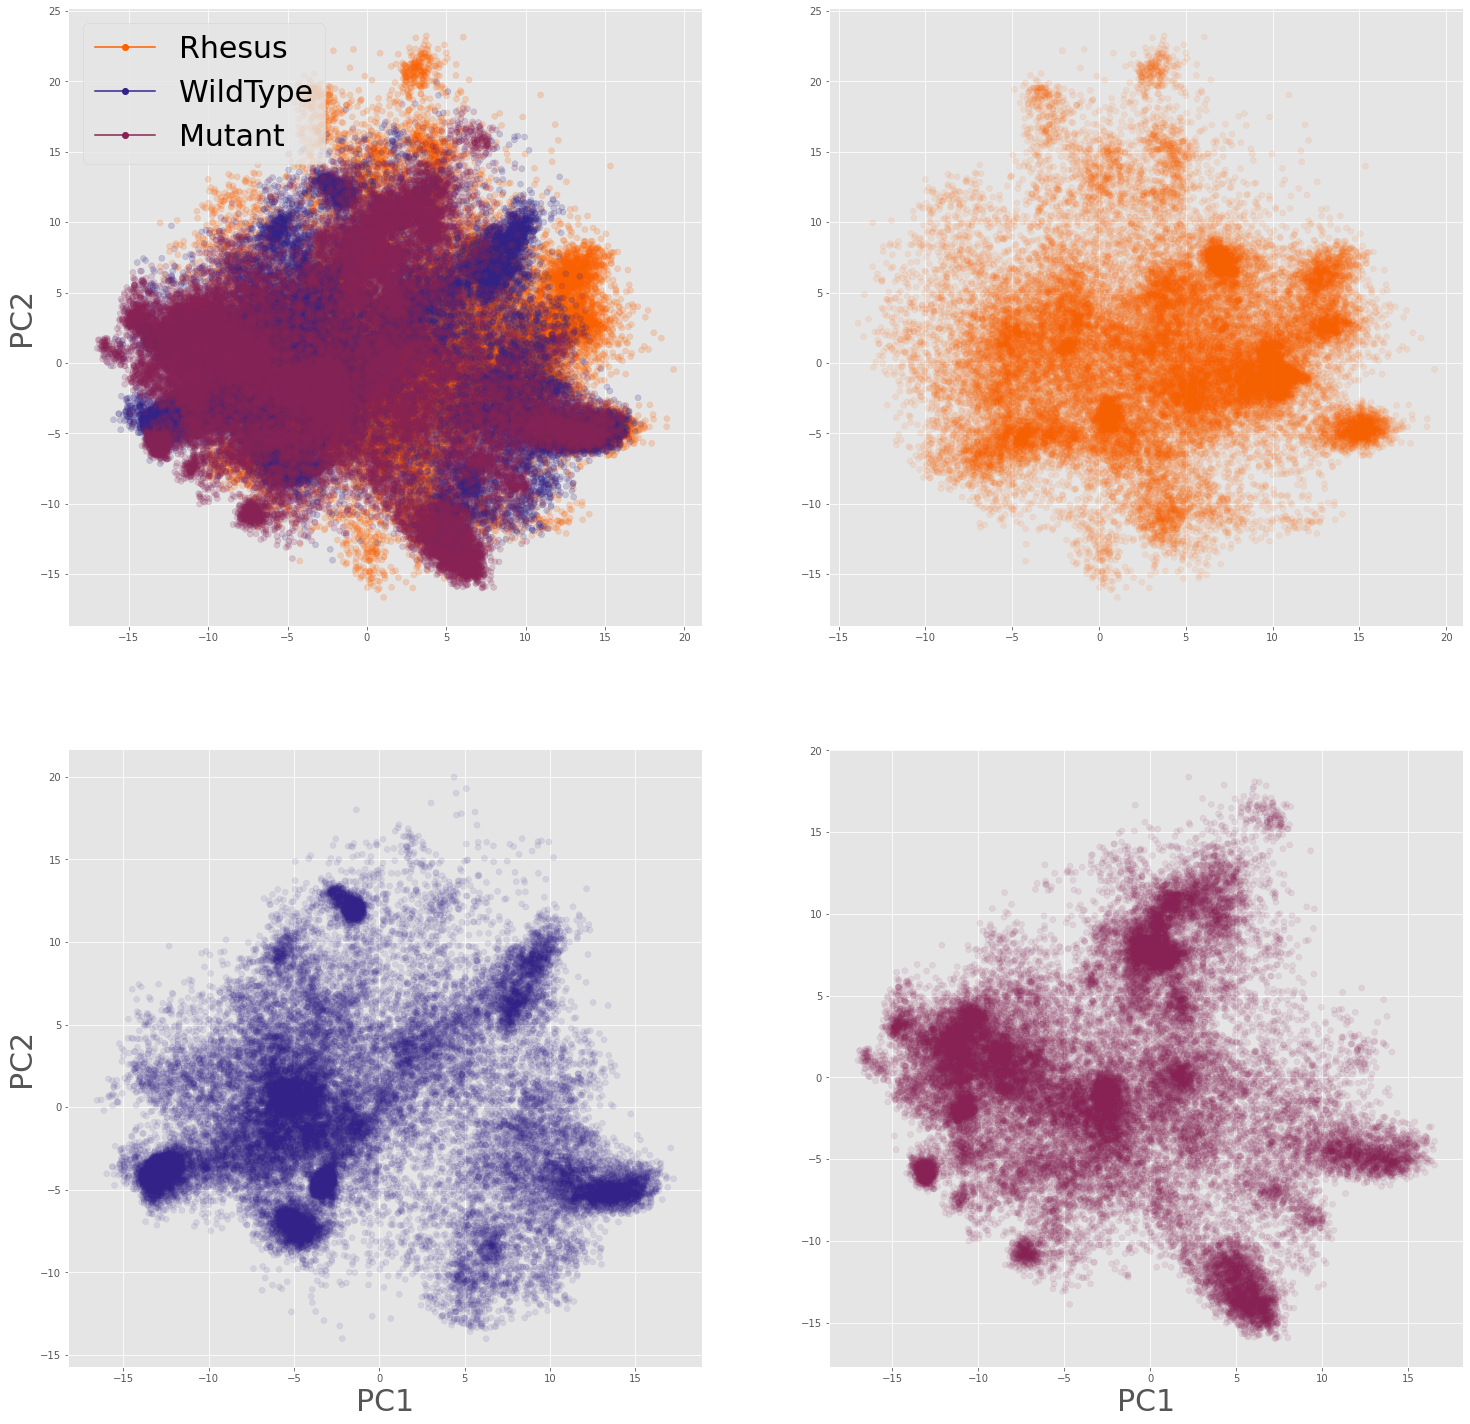

In [7]:
style.use("ggplot")
figure(figsize = (25,25))
#for i in range(len(pcaPoints.T)):
#    scatter(pcaPoints.T[i][0],pcaPoints.T[i][1],color = pca_colours[i],alpha = 0.1)#,color = mycolors[i])#,label = structureList[i][3:])

subplot(2,2,1)
scatter(*pcaPoints,color = pca_colours,alpha = 0.2)
legend_elements = [Line2D([0], [0], marker='o', color=colourScheme[0], label="Rhesus"),
                       Line2D([0], [0], marker='o', color=colourScheme[1], label="WildType"),
                       Line2D([0], [0], marker='o', color=colourScheme[2], label="Mutant")]
legend(handles = legend_elements,loc='best',fontsize = 30)
ylabel("PC2",fontsize = 30)
#ylim(-18,25)
#xlim(-18,21)
#xticks([])
#yticks([])

subplot(2,2,2)
scatter(pcaPoints[0][:int(len(pcaPoints[0])/3)],pcaPoints[1][:int(len(pcaPoints[0])/3)],color = pca_colours[:int(len(pcaPoints[0])/3)],alpha = 0.1)

#xticks([])
#yticks([])
#ylim(-18,25)
#xlim(-18,21)

subplot(2,2,3)
scatter(pcaPoints[0][int(len(pcaPoints[0])/3):2*int(len(pcaPoints[0])/3)],pcaPoints[1][int(len(pcaPoints[0])/3):2*int(len(pcaPoints[0])/3)],color = pca_colours[int(len(pcaPoints[0])/3):2*int(len(pcaPoints[0])/3)],alpha = 0.1)

#xticks([])
#yticks([])
#ylim(-18,25)
#xlim(-18,21)
xlabel("PC1",fontsize = 30)
ylabel("PC2",fontsize = 30)


subplot(2,2,4)
scatter(pcaPoints[0][2*int(len(pcaPoints[0])/3):],pcaPoints[1][2*int(len(pcaPoints[0])/3):],color = pca_colours[2*int(len(pcaPoints[0])/3):],alpha = 0.1)
#xticks([])
#yticks([])
#ylim(-18,25)
#xlim(-18,21)
xlabel("PC1",fontsize = 30)


In [ ]:
style.use("ggplot")
figure(figsize = (25,25))
#for i in range(len(pcaPoints.T)):
#    scatter(pcaPoints.T[i][0],pcaPoints.T[i][1],color = pca_colours[i],alpha = 0.1)#,color = mycolors[i])#,label = structureList[i][3:])

subplot(2,2,1)
scatter(*pcaPoints,color = pca_colours,alpha = 0.2)
legend_elements = [Line2D([0], [0], marker='o', color=colourScheme[0], label="Rhesus"),
                       Line2D([0], [0], marker='o', color=colourScheme[1], label="WildType"),
                       Line2D([0], [0], marker='o', color=colourScheme[2], label="Mutant")]
legend(handles = legend_elements,loc='best',fontsize = 30)
ylabel("PC2",fontsize = 30)
#ylim(-20,45)
#xlim(-20,50)
xticks([])
yticks([])

sns.jointplot(pcaPoints[0][:int(len(pcaPoints[0])/3)],pcaPoints[1][:int(len(pcaPoints[0])/3)],kind = 'kde',shade = True, color=colourScheme[0])

#xticks([])
#yticks([])
#ylim(-20,45)
#xlim(-20,50)
#
sns.jointplot(pcaPoints[0][int(len(pcaPoints[0])/3):2*int(len(pcaPoints[0])/3)],pcaPoints[1][int(len(pcaPoints[0])/3):2*int(len(pcaPoints[0])/3)],kind = 'kde',shade= True, color = colourScheme[1])

#xticks([])
#yticks([])
#ylim(-20,45)
#xlim(-20,50)
xlabel("PC1",fontsize = 30)
ylabel("PC2",fontsize = 30)


sns.jointplot(pcaPoints[0][2*int(len(pcaPoints[0])/3):],pcaPoints[1][2*int(len(pcaPoints[0])/3):],kind = 'kde',shade = True,color=colourScheme[2])
#xticks([])
#yticks([])
#ylim(-20,45)
#xlim(-20,50)
xlabel("PC1",fontsize = 30)


C:\Users\Liam\anaconda3\envs\mda2\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(
C:\Users\Liam\anaconda3\envs\mda2\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


In [ ]:
from sklearn.cluster import DBSCAN 
db1 = DBSCAN(eps=.5,min_samples = 200).fit(array(transformed_dists[0]).reshape(-1,2))
figure(figsize = (8,8))
scatter(array(transformed_dists[0]).reshape(-1,2).T[0],array(transformed_dists[0]).reshape(-1,2).T[1],c = db1.labels_)


In [ ]:
from sklearn.cluster import DBSCAN


db2 = DBSCAN(eps=.5,min_samples = 200).fit(array(transformed_dists[1]).reshape(-1,2))
figure(figsize = (8,8))
scatter(array(transformed_dists[1]).reshape(-1,2).T[0],array(transformed_dists[1]).reshape(-1,2).T[1],c = db2.labels_)


In [ ]:
db3 = DBSCAN(eps=.5,min_samples = 200).fit(array(transformed_dists[2]).reshape(-1,2))
figure(figsize = (8,8))
scatter(array(transformed_dists[2]).reshape(-1,2).T[0],array(transformed_dists[2]).reshape(-1,2).T[1],c = db3.labels_)


In [ ]:
trj_frame_db1_labels = db1.labels_.reshape(9,4001)
trj_frame_db2_labels = db2.labels_.reshape(9,4001)
trj_frame_db3_labels = db3.labels_.reshape(9,4001)



#Rhesus
print("TRJ",where(trj_frame_db1_labels == 0)[0][0],"Frame",where(trj_frame_db1_labels == 0)[1][0])
print("TRJ",where(trj_frame_db1_labels == 1)[0][0],"Frame",where(trj_frame_db1_labels == 1)[1][0])
print("TRJ",where(trj_frame_db1_labels == 2)[0][0],"Frame",where(trj_frame_db1_labels == 2)[1][0])
print("TRJ",where(trj_frame_db1_labels == 3)[0][0],"Frame",where(trj_frame_db1_labels == 3)[1][0])


In [ ]:



#WT
print("TRJ",where(trj_frame_db2_labels == 0)[0][0],where(trj_frame_db2_labels == 0)[1][0])
print("TRJ",where(trj_frame_db2_labels == 1)[0][0],where(trj_frame_db2_labels == 1)[1][0])
print("TRJ",where(trj_frame_db2_labels == 2)[0][0],where(trj_frame_db2_labels == 2)[1][0])
print("TRJ",where(trj_frame_db2_labels == 3)[0][0],where(trj_frame_db2_labels == 3)[1][0])
print("TRJ",where(trj_frame_db2_labels == 4)[0][0],where(trj_frame_db2_labels == 4)[1][0])
print("TRJ",where(trj_frame_db2_labels == 5)[0][0],where(trj_frame_db2_labels == 5)[1][0])


In [ ]:
#RF332P
print("TRJ",where(trj_frame_db3_labels == 0)[0][0],"Frame", where(trj_frame_db3_labels == 0)[1][0])
print("TRJ",where(trj_frame_db3_labels == 1)[0][0],"Frame", where(trj_frame_db3_labels == 1)[1][0])
print("TRJ",where(trj_frame_db3_labels == 2)[0][0],"Frame", where(trj_frame_db3_labels == 2)[1][0])
print("TRJ",where(trj_frame_db3_labels == 3)[0][0],"Frame", where(trj_frame_db3_labels == 3)[1][0])
print("TRJ",where(trj_frame_db3_labels == 4)[0][0],"Frame", where(trj_frame_db3_labels == 4)[1][0])
print("TRJ",where(trj_frame_db3_labels == 5)[0][0],"Frame", where(trj_frame_db3_labels == 5)[1][0])
print("TRJ",where(trj_frame_db3_labels == 6)[0][0],"Frame", where(trj_frame_db3_labels == 6)[1][0])


In [ ]:
with MDAnalysis.Writer("PDBs_to_Dock/PCA_and_DBSCAN_on_v1_CA_distances/state_dbscan_outputs_rhesus_v1_1.pdb") as W:
    
    tu=systems[0][0]
    tu.trajectory[80]
    W.write(tu.select_atoms("protein"))
    
with MDAnalysis.Writer("PDBs_to_Dock/PCA_and_DBSCAN_on_v1_CA_distances/state_dbscan_outputs_rhesus_v1_2.pdb") as W:
    
    tu=systems[0][0]
    tu.trajectory[241]
    W.write(tu.select_atoms("protein"))
    
with MDAnalysis.Writer("PDBs_to_Dock/PCA_and_DBSCAN_on_v1_CA_distances/state_dbscan_outputs_rhesus_v1_3.pdb") as W:
    
    tu=systems[0][1]
    tu.trajectory[407]
    W.write(tu.select_atoms("protein"))
    
with MDAnalysis.Writer("PDBs_to_Dock/PCA_and_DBSCAN_on_v1_CA_distances/state_dbscan_outputs_rhesus_v1_4.pdb") as W:
    
    tu=systems[0][4]
    tu.trajectory[2579]
    W.write(tu.select_atoms("protein"))

In [ ]:
with MDAnalysis.Writer("PDBs_to_Dock/PCA_and_DBSCAN_on_v1_CA_distances/state_dbscan_outputs_wt_v1_1.pdb") as W:
    
    tu=systems[1][0]
    tu.trajectory[39]
    W.write(tu.select_atoms("protein"))
with MDAnalysis.Writer("PDBs_to_Dock/PCA_and_DBSCAN_on_v1_CA_distances/state_dbscan_outputs_wt_v1_2.pdb") as W:
    
    tu=systems[1][0]
    tu.trajectory[310]
    W.write(tu.select_atoms("protein"))
with MDAnalysis.Writer("PDBs_to_Dock/PCA_and_DBSCAN_on_v1_CA_distances/state_dbscan_outputs_wt_v1_3.pdb") as W:
    
    tu=systems[1][0]
    tu.trajectory[276]
    W.write(tu.select_atoms("protein"))
with MDAnalysis.Writer("PDBs_to_Dock/PCA_and_DBSCAN_on_v1_CA_distances/state_dbscan_outputs_wt_v1_4.pdb") as W:
    
    tu=systems[1][1]
    tu.trajectory[649]
    W.write(tu.select_atoms("protein"))
with MDAnalysis.Writer("PDBs_to_Dock/PCA_and_DBSCAN_on_v1_CA_distances/state_dbscan_outputs_wt_v1_5.pdb") as W:
    
    tu=systems[1][3]
    tu.trajectory[787]
    W.write(tu.select_atoms("protein"))
with MDAnalysis.Writer("PDBs_to_Dock/PCA_and_DBSCAN_on_v1_CA_distances/state_dbscan_outputs_wt_v1_6.pdb") as W:
    
    tu=systems[1][1]
    tu.trajectory[846]
    W.write(tu.select_atoms("protein"))


In [ ]:
with MDAnalysis.Writer("PDBs_to_Dock/PCA_and_DBSCAN_on_v1_CA_distances/state_dbscan_outputs_r332p_v1_1.pdb") as W:
    
    tu=systems[2][0]
    tu.trajectory[0]
    W.write(tu.select_atoms("protein"))
with MDAnalysis.Writer("PDBs_to_Dock/PCA_and_DBSCAN_on_v1_CA_distances/state_dbscan_outputs_r332p_v1_2.pdb") as W:
    
    tu=systems[2][0]
    tu.trajectory[293]
    W.write(tu.select_atoms("protein"))
with MDAnalysis.Writer("PDBs_to_Dock/PCA_and_DBSCAN_on_v1_CA_distances/state_dbscan_outputs_r332p_v1_3.pdb") as W:
    
    tu=systems[2][0]
    tu.trajectory[395]
    W.write(tu.select_atoms("protein"))
with MDAnalysis.Writer("PDBs_to_Dock/PCA_and_DBSCAN_on_v1_CA_distances/state_dbscan_outputs_r332p_v1_4.pdb") as W:
    
    tu=systems[2][0]
    tu.trajectory[392]
    W.write(tu.select_atoms("protein"))
with MDAnalysis.Writer("PDBs_to_Dock/PCA_and_DBSCAN_on_v1_CA_distances/state_dbscan_outputs_r332p_v1_5.pdb") as W:
    
    tu=systems[2][0]
    tu.trajectory[819]
    W.write(tu.select_atoms("protein"))
with MDAnalysis.Writer("PDBs_to_Dock/PCA_and_DBSCAN_on_v1_CA_distances/state_dbscan_outputs_r332p_v1_6.pdb") as W:
    
    tu=systems[2][1]
    tu.trajectory[3464]
    W.write(tu.select_atoms("protein"))
with MDAnalysis.Writer("PDBs_to_Dock/PCA_and_DBSCAN_on_v1_CA_distances/state_dbscan_outputs_r332p_v1_7.pdb") as W:
    
    tu=systems[2][3]
    tu.trajectory[3250]
    W.write(tu.select_atoms("protein"))
